In [1]:
import os
from scipy.signal import spectrogram 
from scipy.io import wavfile
import numpy as np
from PIL import Image
from matplotlib.colors import Normalize
import matplotlib.pyplot as plt

In [2]:
#Does not need to run each time 
#parameters for the split audio function 
input_file =r"C:\Users\yusle\OneDrive\Desktop\boat_audio\audio\noise_target数据集\noise_target数据集\noise_未切分\DATA0001\DATA0033.wav"
output_dir='NoiseFragments2'
os.makedirs(output_dir, exist_ok=True)
chunk_duration=3
startingfilenumber=100


In [2]:
#Does not need to run eah time 
#Function Def for turning larger audio files into smaller 3 second fragments 
import os
import numpy as np
import librosa
import soundfile as sf

def split_audio_into_chunks(input_file, output_dir, chunk_duration=3,startingfilenumber=0):
    os.makedirs(output_dir, exist_ok=True)
    
    # Load audio file
    y, sr = librosa.load(input_file, sr=None)  # keep original sample rate
    
    chunk_samples = chunk_duration * sr
    total_samples = len(y)
    
    num_chunks = total_samples // chunk_samples
    
    for i in range(num_chunks):
        start = i * chunk_samples
        end = start + chunk_samples
        chunk = y[start:end]
        
        output_path = os.path.join(output_dir, f"chunk_{startingfilenumber:04d}.wav")
        sf.write(output_path, chunk, sr)
        startingfilenumber+=1
       
    
    print(f"Saved {num_chunks} chunks to {output_dir}")



In [ ]:
#Does not need to run each time 
#Usage for the split_audio function 
split_audio_into_chunks(input_file, output_dir, chunk_duration,startingfilenumber)

Saved 100 chunks to NoiseFragments2


In [ ]:
#Does not need to run each time
#function for combining folder files into one
import os
import shutil

def combine_folders(source_folders, destination_folder, move_files=False):
    """
    Combines contents of multiple folders into a single folder.
    
    Parameters:
        source_folders (list): List of folder paths to combine
        destination_folder (str): Target folder path
        move_files (bool): If True, moves files. If False, copies files.
    """
    
    os.makedirs(destination_folder, exist_ok=True)
    
    for folder in source_folders:
        for root, _, files in os.walk(folder):
            for file in files:
                source_path = os.path.join(root, file)
                
                # Handle duplicate filenames
                base_name = file
                name, ext = os.path.splitext(base_name)
                counter = 1
                dest_path = os.path.join(destination_folder, base_name)
                
                while os.path.exists(dest_path):
                    new_name = f"{name}_{counter}{ext}"
                    dest_path = os.path.join(destination_folder, new_name)
                    counter += 1
                
                if move_files:
                    shutil.move(source_path, dest_path)
                else:
                    shutil.copy2(source_path, dest_path)

    print("Done combining folders.")


In [ ]:
#Does not need to run each time 
#using combin_folders function
source_dirs = [
    r"C:\Users\yusle\OneDrive\Desktop\boat_audio\NoiseFragments1",
    r"C:\Users\yusle\OneDrive\Desktop\boat_audio\NoiseFragments2"
    
]

combine_folders(source_dirs, "combined_noise", move_files=False)


Done combining folders.


In [11]:
audio_folder=r'C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss'
output_folder='W4_spec'
os.makedirs(output_folder, exist_ok=True)

In [3]:
# We need to create parmeters for the spectrogram
freq_min=10
freq_max=1000
window_size=1024
overlapp=800
n_fft=1024*4  #2^10

In [13]:
#loop for turning audio files in the directed folder into spectrogram with a mask and then normilzing it and saving the image to the output folder
for file in os.listdir(audio_folder):
    file_path= os.path.join(audio_folder,file)
    print(file_path)
    fs,x=wavfile.read(file_path)
    f,t,S=spectrogram(x,fs,nperseg=window_size,noverlap=overlapp,nfft=n_fft)
    f_mask=(f>=freq_min)&(f<=freq_max)
    sxx=S[f_mask,:]
    G=10*np.log10(sxx+1e-8)
    G=np.flipud(G)
    # normalize the spectrogram
    norm=Normalize(vmin=np.min(G),vmax=np.max(G))
    G_normalized=norm(G)
    # convert spectrogram to image
    G_colormap=plt.cm.jet( G_normalized)
    G_image=( G_colormap[:,:,:3]*255).astype(np.uint8)
    G_resized=Image.fromarray(G_image).resize((224,224))
    output_file=os.path.join(output_folder,os.path.basename(file_path).replace('.wav','.png'))
    G_resized.save(  output_file)
    
        
    

C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_1.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_10.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_100.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_101.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_102.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_103.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_104.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_105.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_106.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_107.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_108.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_109.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_11.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_110.wav
C:\Users\yusle\OneDrive\Desktop\Whale_audio\Riss\Riss\10_111.wav
C:\Users\yusle\OneDrive\Deskt

In [4]:
# create model for training
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
#for splitting folder with subfolder classes into folder with train and validation 70/30 split folder and each having all the subfolder classes  
import os
import shutil
import random

# ===== CONFIG =====
source_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec"   # folder with class subfolders
train_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec_split\Train"
test_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec_split\Val"
split_ratio = 0.7
random_seed = 42
# ==================

random.seed(random_seed)

# Create Train and Test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Loop over each class folder
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Create class folders in Train and Test
    train_class_dir = os.path.join(train_dir, class_name)
    test_class_dir = os.path.join(test_dir, class_name)

    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # Get all image files
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random.shuffle(images)

    split_index = int(len(images) * split_ratio)
    train_images = images[:split_index]
    test_images = images[split_index:]

    # Copy files
    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(train_class_dir, img)
        )

    for img in test_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(test_class_dir, img)
        )

    print(f"{class_name}: {len(train_images)} train / {len(test_images)} test")

print("✅ Dataset split complete.")


W1_spec: 2506 train / 1074 test
W2_spec: 3304 train / 1417 test
W3_spec: 1502 train / 645 test
W4_spec: 2293 train / 984 test
✅ Dataset split complete.


In [2]:
#for splitting folder with subfolder classes into folder with train, validation, and test 70/15/15 split folder and each having all the subfolder classes  
import os
import shutil
import random

# ===== CONFIG =====
source_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec"   # folder with class subfolders
train_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec_split_better\Train"
val_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec_split_better\Val"
test_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec_split_better\Test"
train_ratio = 0.7
val_ratio = 0.15
test_ratio = 0.15
random_seed = 42
# ==================

random.seed(random_seed)

# Create Train, Val, and Test directories
os.makedirs(train_dir, exist_ok=True)
os.makedirs(val_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

# Loop over each class folder
for class_name in os.listdir(source_dir):
    class_path = os.path.join(source_dir, class_name)

    if not os.path.isdir(class_path):
        continue

    # Create class folders in Train, Val, and Test
    train_class_dir = os.path.join(train_dir, class_name)
    val_class_dir = os.path.join(val_dir, class_name)
    test_class_dir = os.path.join(test_dir, class_name)

    os.makedirs(train_class_dir, exist_ok=True)
    os.makedirs(val_class_dir, exist_ok=True)
    os.makedirs(test_class_dir, exist_ok=True)

    # Get all image files
    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith((".png", ".jpg", ".jpeg"))
    ]

    random.shuffle(images)

    # Calculate split indices
    train_index = int(len(images) * train_ratio)
    val_index = train_index + int(len(images) * val_ratio)
    
    train_images = images[:train_index]
    val_images = images[train_index:val_index]
    test_images = images[val_index:]

    # Copy files to Train folder
    for img in train_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(train_class_dir, img)
        )

    # Copy files to Val folder
    for img in val_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(val_class_dir, img)
        )

    # Copy files to Test folder
    for img in test_images:
        shutil.copy2(
            os.path.join(class_path, img),
            os.path.join(test_class_dir, img)
        )

    print(f"{class_name}: {len(train_images)} train / {len(val_images)} val / {len(test_images)} test")

print("✅ Dataset split complete (70/15/15).")

W1_spec: 2506 train / 537 val / 537 test
W2_spec: 3304 train / 708 val / 709 test
W3_spec: 1502 train / 322 val / 323 test
W4_spec: 2293 train / 491 val / 493 test
✅ Dataset split complete (70/15/15).


In [16]:
# prepare data
data_dir = r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec_split_better"  # Replace with your folder path
# Hyperparameters
batch_size = 16
num_epochs = 20
learning_rate = 0.001
num_classes =4  # Number of subfolders-(each folder is a class)
print(num_classes)

# Image transformations
transform = transforms.Compose([transforms.ToTensor()])

4


In [6]:
# Load dataset
train_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "Train"), transform=transform)
val_dataset = datasets.ImageFolder(root=os.path.join(data_dir, "Val"), transform=transform)

In [7]:

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [8]:
class ViTModel(nn.Module):
    def __init__(self, num_classes):
        super(ViTModel, self).__init__()
        # Load pretrained Vision Transformer model
        self.model = models.vit_b_16(pretrained=True)
        
        # Replace the head (classification layer)
        in_features = self.model.heads.head.in_features  # Get input features of the head
        self.model.heads.head = nn.Linear(in_features, num_classes)  # Replace with new classification layer

    def forward(self, x):
        return self.model(x)

In [9]:
import torch

print(torch.cuda.is_available())
print(torch.cuda.device_count())
print(torch.cuda.get_device_name(0))

True
1
NVIDIA GeForce RTX 3070


In [10]:
class ResNet18Model(nn.Module):
    def __init__(self, num_classes):
        super(ResNet18Model, self).__init__()
        
        self.model = models.resnet18(pretrained=True)
        
        # Replace final fully connected layer
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [10]:
class ResNet50Model(nn.Module):
    def __init__(self, num_classes):
        super(ResNet50Model, self).__init__()
        
        self.model = models.resnet50(pretrained=True)
        
        # Replace final fully connected layer
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [8]:
#declaring the efficentNetModel structure 
class EfficientNetModel(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetModel, self).__init__()
        self.model = models.efficientnet_b0(pretrained=True)
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [11]:
class EfficientNetModel_Mine(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(pretrained=True)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(p=0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.1),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [31]:
#declaring the efficentNetModel b3 structure 
class EfficientNetModel(nn.Module):
    def __init__(self, num_classes):
        super(EfficientNetModel, self).__init__()
        self.model = models.efficientnet_b3(pretrained=True)
        self.model.classifier[1] = nn.Linear(self.model.classifier[1].in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [12]:
# Initialize models, loss function, and optimizer
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

#loading the models to the device and declaring them
vit_model = ViTModel(num_classes).to(device)
efficientnet_model = EfficientNetModel_Mine(num_classes).to(device)
resnet_model = ResNet18Model(num_classes).to(device)

#loss function and optimizers for each model
criterion = nn.CrossEntropyLoss()
vit_optimizer = optim.Adam(vit_model.parameters(), lr=learning_rate)
efficientnet_optimizer = optim.Adam(efficientnet_model.parameters(), lr=learning_rate)
resnet_optimizer = optim.Adam(resnet_model.parameters(), lr=learning_rate)


cuda


c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ViT_B_16_Weights.IMAGENET1K_V1`. You can also use `weights=ViT_B_16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_W

In [ ]:
def train_model(model, optimizer, train_loader, val_loader, num_epochs, model_name):
    maxAccuracy=80
    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        for inputs, labels in tqdm(train_loader, desc=f"Training {model_name} Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_loader.dataset)

        # Validation phase
        model.eval()
        val_loss = 0.0
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        val_loss /= len(val_loader.dataset)
        accuracy = correct / total * 100

        print(f"{model_name} Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, "
              f"Val Loss: {val_loss:.4f}, Val Accuracy: {accuracy:.2f}%")
        #saving best model 
        if accuracy > maxAccuracy: 
            torch.save(efficientnet_model.state_dict(), 'efficientnet_model.pth')
            maxAccuracy=accuracy
            print(f"Saved model with best accuracy of {maxAccuracy:.2f}%")
        


In [15]:
def train_model(model, optimizer, train_loader, val_loader, num_epochs, model_name, num_classes):
    max_mean_accuracy = 95

    for epoch in range(num_epochs):

        # ------------------ TRAIN ------------------
        model.train()
        train_loss = 0.0

        for inputs, labels in tqdm(train_loader, desc=f"Training {model_name} Epoch {epoch+1}/{num_epochs}"):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_loader.dataset)

        # ------------------ VALIDATION ------------------
        model.eval()
        val_loss = 0.0

        correct = 0
        total = 0

        # Per-class tracking
        class_correct = torch.zeros(num_classes)
        class_total = torch.zeros(num_classes)

        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                outputs = model(inputs)
                loss = criterion(outputs, labels)

                val_loss += loss.item() * inputs.size(0)

                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

                # Per-class stats
                for i in range(len(labels)):
                    label = labels[i]
                    class_total[label] += 1
                    if predicted[i] == label:
                        class_correct[label] += 1

        val_loss /= len(val_loader.dataset)
        overall_accuracy = 100 * correct / total

        # Compute per-class accuracy
        class_accuracies = 100 * class_correct / class_total.clamp(min=1)

        # Mean class accuracy (balanced accuracy)
        mean_class_accuracy = class_accuracies.mean().item()

        # ------------------ PRINT METRICS ------------------
        print(f"\n{model_name} Epoch {epoch+1}/{num_epochs}")
        print(f"Train Loss: {train_loss:.4f}")
        print(f"Val Loss: {val_loss:.4f}")
        print(f"Overall Accuracy: {overall_accuracy:.2f}%")
        print(f"Mean Class Accuracy: {mean_class_accuracy:.2f}%")

        for i in range(num_classes):
            print(f"Class {i} Accuracy: {class_accuracies[i]:.2f}%")

        # ------------------ SAVE BEST MODEL ------------------
        if class_accuracies[0] > 95 and class_accuracies[1] > 95 and class_accuracies[2] > 95 and class_accuracies[3] > 95:
            torch.save(model.state_dict(), f"{model_name}_bestM_whale_cm_{mean_class_accuracy:.2f}%_c1_{class_accuracies[0]:.2f}%_c2_{class_accuracies[1]:.2f}%_c3_{class_accuracies[2]:.2f}%_c4_{class_accuracies[3]:.2f}%.pth")
            max_mean_accuracy = mean_class_accuracy
            print(f"Saved best model with Mean Class Accuracy: {max_mean_accuracy:.2f}%\n")
        elif mean_class_accuracy > max_mean_accuracy:
            torch.save(model.state_dict(), f"{model_name}_bestM_whale_{mean_class_accuracy:.2f}%.pth")
            max_mean_accuracy = mean_class_accuracy
            print(f"Saved best model with Mean Class Accuracy: {max_mean_accuracy:.2f}%\n")
        
        


In [ ]:

# Train Vision Transformer
train_model(vit_model, vit_optimizer, train_loader, val_loader, num_epochs, "ViT",num_classes)

In [17]:
#train resnet18
train_model(resnet_model, resnet_optimizer, train_loader, val_loader, num_epochs, "ResNet18", num_classes)

Training ResNet18 Epoch 1/20: 100%|██████████| 301/301 [00:33<00:00,  8.99it/s]



ResNet18 Epoch 1/20
Train Loss: 0.0844
Val Loss: 0.0648
Overall Accuracy: 97.57%
Mean Class Accuracy: 97.61%
Class 0 Accuracy: 91.06%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 99.38%
Class 3 Accuracy: 100.00%
Saved best model with Mean Class Accuracy: 97.61%



Training ResNet18 Epoch 2/20: 100%|██████████| 301/301 [00:32<00:00,  9.31it/s]



ResNet18 Epoch 2/20
Train Loss: 0.0463
Val Loss: 0.0287
Overall Accuracy: 98.69%
Mean Class Accuracy: 98.65%
Class 0 Accuracy: 95.53%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 99.07%
Class 3 Accuracy: 100.00%
Saved best model with Mean Class Accuracy: 98.65%



Training ResNet18 Epoch 3/20: 100%|██████████| 301/301 [00:32<00:00,  9.28it/s]


...


ResNet18 Epoch 18/20
Train Loss: 0.0226
Val Loss: 0.0197
Overall Accuracy: 99.13%
Mean Class Accuracy: 98.63%
Class 0 Accuracy: 99.81%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 94.72%
Class 3 Accuracy: 100.00%


Training ResNet18 Epoch 19/20: 100%|██████████| 301/301 [00:33<00:00,  9.07it/s]



ResNet18 Epoch 19/20
Train Loss: 0.0273
Val Loss: 0.0127
Overall Accuracy: 99.47%
Mean Class Accuracy: 99.33%
Class 0 Accuracy: 98.88%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 98.45%
Class 3 Accuracy: 100.00%
Saved best model with Mean Class Accuracy: 99.33%



Training ResNet18 Epoch 20/20: 100%|██████████| 301/301 [00:32<00:00,  9.28it/s]



ResNet18 Epoch 20/20
Train Loss: 0.0076
Val Loss: 0.0152
Overall Accuracy: 99.42%
Mean Class Accuracy: 99.22%
Class 0 Accuracy: 99.07%
Class 1 Accuracy: 100.00%
Class 2 Accuracy: 97.83%
Class 3 Accuracy: 100.00%
Saved best model with Mean Class Accuracy: 99.22%



In [ ]:
# Train EfficientNet
train_model(efficientnet_model, efficientnet_optimizer, train_loader, val_loader, num_epochs, "EfficientNet", num_classes)


In [1]:
# create model for training
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
from tqdm import tqdm

In [2]:
class EfficientNetModel_Mine(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.model = models.efficientnet_b0(pretrained=False)

        in_features = self.model.classifier[1].in_features
        self.model.classifier = nn.Sequential(
            nn.Dropout(p=0.4),
            nn.Linear(in_features, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(p=0.3),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=0.2),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(p=0.1),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.model(x)

In [3]:
class ResNet18Model(nn.Module):
    def __init__(self, num_classes):
        super(ResNet18Model, self).__init__()
        
        self.model = models.resnet18(pretrained=False)
        
        # Replace final fully connected layer
        self.model.fc = nn.Linear(self.model.fc.in_features, num_classes)

    def forward(self, x):
        return self.model(x)

In [4]:
# test_folder=r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\whale_spec\W4_spec"

MainFolderList = [r"whale_spec_split_better/Test/W1_spec", r"whale_spec_split_better/Test/W2_spec", r"whale_spec_split_better/Test/W3_spec", r"whale_spec_split_better/Test/W4_spec"]

# MainFolderList=[r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\Underwater_noise_combined_spec\U1_spec_combined",r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\Underwater_noise_combined_spec\U2_spec_combined",r"C:\Users\yusle\OneDrive\Desktop\Git Hub Repositories\OSINModels2\Underwater_noise_combined_spec\U3_spec_combined"]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 4  # MUST match training
model = ResNet18Model(num_classes).to(device)

model.load_state_dict(torch.load("ResNet18_bestM_whale_cm_99.52%_c1_98.70%_c2_100.00%_c3_99.38%_c4_100.00%.pth", map_location=device))

model.eval()  # VERY IMPORTANT


c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\yusle\AppData\Local\Programs\Python\Python310\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


ResNet18Model(
  (model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): BasicBlock(
        (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track

CLASS BLAIN PREDICTION SUMMARY
Blain: 530
Bottle: 0
Pilot: 7
Riss: 0
Class Accuracy on Unseen Data: 0.9869646182495344
CLASS BOTTLE PREDICTION SUMMARY
Blain: 0
Bottle: 709
Pilot: 0
Riss: 0
Class Accuracy on Unseen Data: 1.0
CLASS PILOT PREDICTION SUMMARY
Blain: 3
Bottle: 0
Pilot: 320
Riss: 0
Class Accuracy on Unseen Data: 0.9907120743034056
CLASS RISS PREDICTION SUMMARY
Blain: 0
Bottle: 0
Pilot: 0
Riss: 493
Class Accuracy on Unseen Data: 1.0

COMPREHENSIVE METRICS FOR ALL CLASSES

PER-CLASS METRICS:
----------------------------------------------------------------------

BLAIN:
  Precision:   0.9944 (99.44%)
  Recall:      0.9870 (98.70%)
  Sensitivity: 0.9870 (98.70%)
  Specificity: 0.9980 (99.80%)
  F1-Score:    0.9907
  TP: 530, FP: 3, TN: 1522, FN: 7

BOTTLE:
  Precision:   1.0000 (100.00%)
  Recall:      1.0000 (100.00%)
  Sensitivity: 1.0000 (100.00%)
  Specificity: 1.0000 (100.00%)
  F1-Score:    1.0000
  TP: 709, FP: 0, TN: 1353, FN: 0

PILOT:
  Precision:   0.9786 (97.86%)
  Re

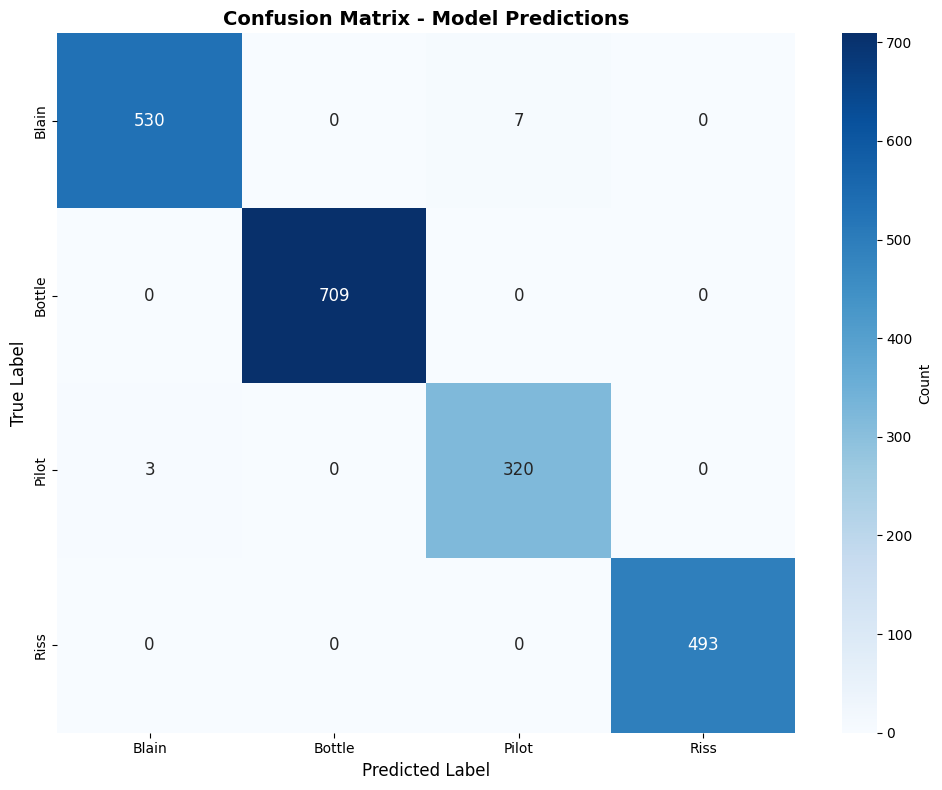

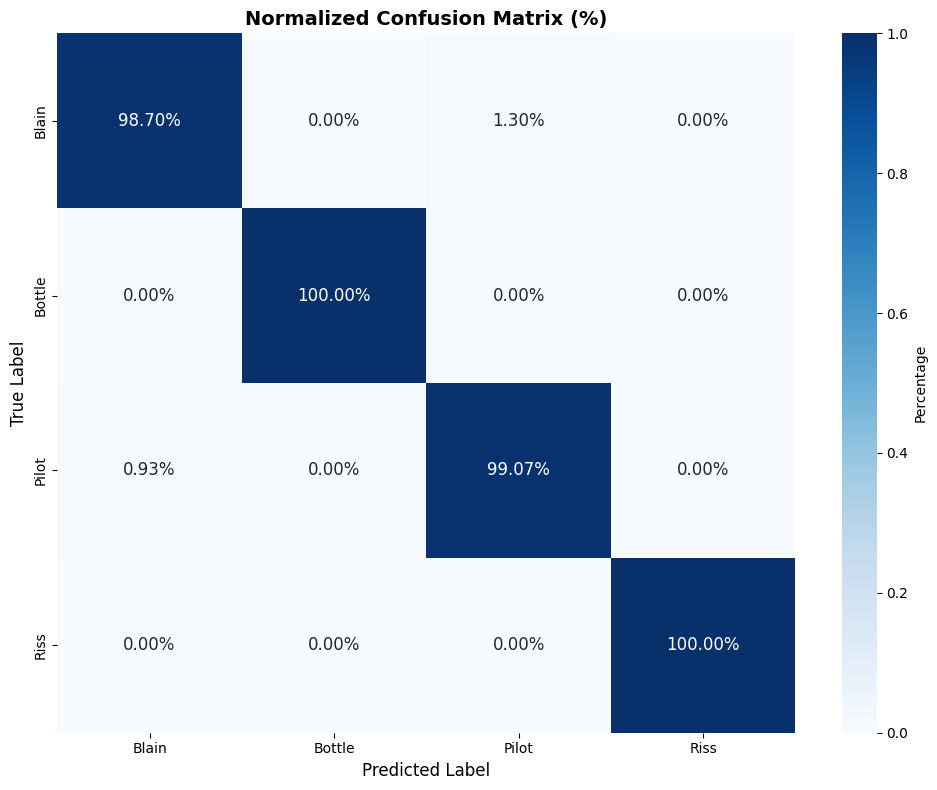


CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Blain     0.9944    0.9870    0.9907       537
      Bottle     1.0000    1.0000    1.0000       709
       Pilot     0.9786    0.9907    0.9846       323
        Riss     1.0000    1.0000    1.0000       493

    accuracy                         0.9952      2062
   macro avg     0.9932    0.9944    0.9938      2062
weighted avg     0.9952    0.9952    0.9952      2062



In [6]:
import os
from PIL import Image
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report, precision_recall_fscore_support

# Define normalized transform (same as training)
transform_inference = transforms.Compose([
    transforms.ToTensor(),
    # transforms.Normalize(mean=[0.485, 0.456, 0.406], 
    #                      std=[0.229, 0.224, 0.225])
])

model.eval()

class_names = ["Blain", "Bottle", "Pilot","Riss"]  # adjust to YOUR classes

# Storage for all predictions and ground truth
all_predictions = []
all_ground_truth = []
per_class_metrics = {class_name: {'TP': 0, 'FP': 0, 'TN': 0, 'FN': 0} for class_name in class_names}

class_name_index = 0

for test_folder in MainFolderList:  # Loop through multiple test folders if needed

    # Initialize counters for each class
    class_counts = {class_name: 0 for class_name in class_names}
    
    # Get the true label from folder structure
    # Assuming folder structure is like: whale_spec_split_better/Test/W1_spec
    true_label_name = os.path.basename(test_folder)  # e.g., "W1_spec"
    
    # Map folder name to actual class name
    folder_to_class = {
        "W1_spec": 0,  # Blain
        "W2_spec": 1,  # Bottle
        "W3_spec": 2,  # Pilot
        "W4_spec": 3   # Riss
    }
    
    true_class_idx = folder_to_class.get(true_label_name, class_name_index)
    true_label = class_names[true_class_idx]

    for file in os.listdir(test_folder):
        file_path = os.path.join(test_folder, file)

        # ✅ Skip non-image files
        if not file.lower().endswith((".png", ".jpg", ".jpeg", ".bmp", ".webp")):
            continue

        try:
            # Load + preprocess with ImageNet normalization
            image = Image.open(file_path).convert("RGB")
            input_tensor = transform_inference(image).unsqueeze(0).to(device)

            # Inference
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = torch.softmax(outputs, dim=1)
                pred = torch.argmax(probs, dim=1)

            # Output
            predicted_label = class_names[pred.item()]
            predicted_idx = pred.item()
            confidence = probs.max().item()

            # Store for confusion matrix
            all_predictions.append(predicted_idx)
            all_ground_truth.append(true_class_idx)

            # Increment counter for this class
            class_counts[predicted_label] += 1
            
            # Update confusion matrix components for each class
            for idx, cls_name in enumerate(class_names):
                if predicted_idx == idx and true_class_idx == idx:
                    per_class_metrics[cls_name]['TP'] += 1
                elif predicted_idx == idx and true_class_idx != idx:
                    per_class_metrics[cls_name]['FP'] += 1
                elif predicted_idx != idx and true_class_idx == idx:
                    per_class_metrics[cls_name]['FN'] += 1
                else:
                    per_class_metrics[cls_name]['TN'] += 1

        except Exception as e:
            print(f"Error processing {file}: {e}")
    
    # Print summary
    print("="*70)
    print(f"CLASS {class_names[true_class_idx].upper()} PREDICTION SUMMARY")
    print("="*70)
    for class_name, count in class_counts.items():
        print(f"{class_name}: {count}")
    print("Class Accuracy on Unseen Data:", class_counts[class_names[true_class_idx]] / sum(class_counts.values()) if sum(class_counts.values()) > 0 else 0)
    print("="*70)
    class_name_index += 1

# ================== COMPREHENSIVE METRICS ==================
print("\n" + "="*70)
print("COMPREHENSIVE METRICS FOR ALL CLASSES")
print("="*70)

# Convert to numpy arrays for confusion matrix
all_predictions = np.array(all_predictions)
all_ground_truth = np.array(all_ground_truth)

# Calculate confusion matrix
cm = confusion_matrix(all_ground_truth, all_predictions, labels=range(len(class_names)))

# Print detailed metrics for each class
print("\nPER-CLASS METRICS:")
print("-" * 70)

for idx, class_name in enumerate(class_names):
    TP = per_class_metrics[class_name]['TP']
    FP = per_class_metrics[class_name]['FP']
    TN = per_class_metrics[class_name]['TN']
    FN = per_class_metrics[class_name]['FN']
    
    # Calculate metrics
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0  # Also called Recall
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    recall = sensitivity  # Same as sensitivity
    f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"\n{class_name.upper()}:")
    print(f"  Precision:   {precision:.4f} ({precision*100:.2f}%)")
    print(f"  Recall:      {recall:.4f} ({recall*100:.2f}%)")
    print(f"  Sensitivity: {sensitivity:.4f} ({sensitivity*100:.2f}%)")
    print(f"  Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
    print(f"  F1-Score:    {f1_score:.4f}")
    print(f"  TP: {TP}, FP: {FP}, TN: {TN}, FN: {FN}")

# Overall metrics using sklearn
precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
    all_ground_truth, all_predictions, average='weighted'
)

print("\n" + "-" * 70)
print("OVERALL METRICS:")
print(f"  Weighted Precision: {precision_weighted:.4f} ({precision_weighted*100:.2f}%)")
print(f"  Weighted Recall:    {recall_weighted:.4f} ({recall_weighted*100:.2f}%)")
print(f"  Weighted F1-Score:  {f1_weighted:.4f}")
print("-" * 70)

# ================== CONFUSION MATRIX VISUALIZATION ==================
print("\nConfusion Matrix:")
print(cm)

# Create a beautiful confusion matrix heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Count'}, annot_kws={'size': 12})
plt.title('Confusion Matrix - Model Predictions', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Normalized confusion matrix (percentages)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(10, 8))
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            cbar_kws={'label': 'Percentage'}, annot_kws={'size': 12})
plt.title('Normalized Confusion Matrix (%)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# Classification report
print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print("="*70)
print(classification_report(all_ground_truth, all_predictions, 
                          target_names=class_names, digits=4))